# Libraries

In [1]:
import pylab as pl
import numpy as np
from astropy.visualization import quantity_support
from astropy import units as u
import string
from astropy import wcs

pl.rcParams['figure.facecolor']='w'

from spectral_cube import SpectralCube
from pvextractor import extract_pv_slice, Path
import matplotlib.pyplot as plt
from astropy.wcs import WCS

import pyspeckit
import astropy.units as u
import astropy.wcs as wcs
import aplpy as aplpy
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord

from matplotlib.patches import Ellipse
from matplotlib.patches import Circle

from skimage.morphology import remove_small_objects
from astropy.stats import mad_std

In [7]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Functions

In [2]:
def plot_contours(data_array, color, sigma_m0, sigma_min, sigma_max, sigma_step):
    """
    Plot contours in units of sigma.

    Parameters
    ----------
    data_array : 2D array
        Moment-0 map.
    color : str
        Contour color.
    sigma_m0 : float
        1-sigma moment-0 noise.
    sigma_min, sigma_max : int
        Minimum and maximum sigma levels.
    sigma_step : int
        Step in sigma units.
    """

    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma_m0 * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ],
    )


def beam(beam_minor, beam_major, beam_pa, beam_position):
    # Set beam location
    beam_x = ra_offsets.min() + beam_position + 1
    beam_y = dec_offsets.min() + beam_position

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )


def mask_cube_by_snr(cube, spectral_axis, noise_range=(0.0, 10.5)*u.km/u.s,
                      snr_min=3.5, min_size=80, plot=False):
    """
    Create a mask based on signal-to-noise ratio (SNR) for a spectral cube,
    and remove small isolated regions from the mask.

    Parameters
    ----------
    cube : SpectralCube
        The spectral cube to mask.
    spectral_axis : Quantity array
        The spectral axis of the cube (in velocity units).
    noise_range : tuple (min, max) Quantity
        Velocity range without emission to compute RMS.
    snr_min : float
        Minimum SNR to consider a pixel valid.
    min_size : int
        Minimum number of connected pixels to keep in the mask.
    plot : bool, optional
        If True, plots RMS, Tpeak, SNR, and mask for inspection.

    Returns
    -------
    cube_masked : SpectralCube
        Cube masked according to the SNR and cleaned mask.
    planemask_ed : 2D bool array
        The boolean mask after removing small objects.
    rms, Tpeak, peaksnr : 2D arrays
        Optional arrays of RMS, peak intensity, and SNR for inspection.
    """
    # 1. Select channels without emission to measure noise
    gd = (spectral_axis <= noise_range[0]) | (spectral_axis >= noise_range[1])
    cube_noise = cube.with_mask(gd[:, np.newaxis, np.newaxis])

    # 2. Compute RMS map
    rms = cube_noise.std(axis=0)

    # 3. Compute peak intensity map from full cube
    Tpeak = cube.max(axis=0)

    # 4. Compute SNR map
    peaksnr = Tpeak / rms

    # 5. Make mask based on SNR threshold
    planemask = (peaksnr > snr_min)

    # 6. Remove small isolated regions
    planemask_ed = remove_small_objects(planemask, min_size=min_size)

    # 7. Apply mask to all channels
    cube_masked = cube.with_mask(planemask_ed[np.newaxis, :, :])

    return cube_masked, planemask_ed, rms, Tpeak, peaksnr



# Read Cube and Find RMS Value

In [3]:
cube = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits')
cube = cube.to(u.K).with_spectral_unit(u.km/u.s)

In [14]:
vmin_13CO = 1.4
vmax_13CO = 9.8

# Finding Sigma:
noise_slab = cube.spectral_slab(11.7*u.km/u.s, 13.4*u.km/u.s)
data = noise_slab.unmasked_data[:].value  # strip units
sigma_chan = mad_std(data, ignore_nan=True)
dv = np.abs(cube.spectral_axis[1] - cube.spectral_axis[0])
dv = dv.to(u.km/u.s)

slab_with_emission = cube.spectral_slab(vmin_13CO*u.km/u.s, vmax_13CO*u.km/u.s)
Nchan = slab_with_emission.shape[0]
sigma_m0_13CO = sigma_chan * dv.value * np.sqrt(Nchan)

print("Per-channel RMS:", sigma_chan, noise_slab.unit)
print("Channel width:", dv)
print("Number of channels:", Nchan)
print("Moment-0 sigma:", sigma_m0_13CO, "Jy/beam km/s")

Per-channel RMS: 0.22422759687768704 K
Channel width: 0.08302753949584 km / s
Number of channels: 102
Moment-0 sigma: 0.1880231465287596 Jy/beam km/s


# Set Offset

In [15]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube.hdu.data

# Convert pixel grid to world coordinates
nx = cube.shape[1]
ny = cube.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube.wcs.celestial)

# 13CO Channel Maps

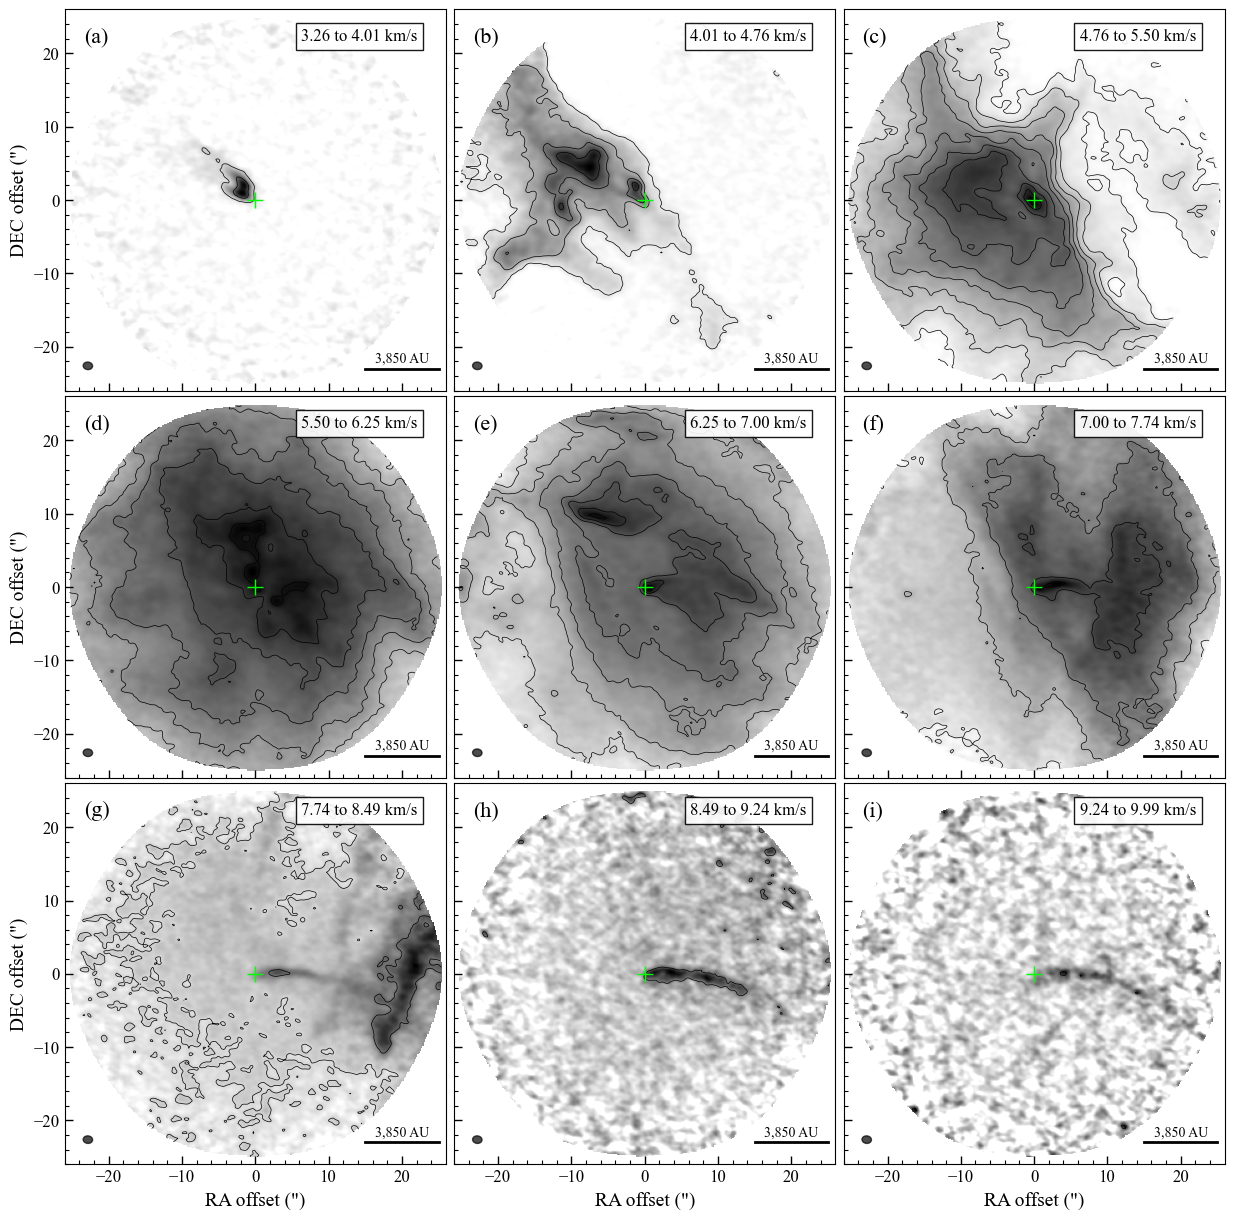

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for idx, i in enumerate(range(38, 117, 9)):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Define the start and stop channels for the moment 0 map
    start_chan = i
    end_chan = i + 9

    # Collapse the 5 channels into a moment 0 map (integrated intensity)
    moment0 = cube[start_chan:end_chan].moment0().value

    # Plot the moment 0 map
    im = ax.imshow(moment0, cmap='binary', origin='lower', vmin=0, extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()])
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.05, 0.955, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Plot contours with proper data handling
    plot_contours(moment0, 'black', sigma_m0_13CO, sigma_min=2, sigma_max=50, sigma_step=5)
    # plot_contours(Mom0_red.value, 'red', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])
    # plot_contours(Mom0_blue.value, 'blue', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])

    # Get velocity for the current slice
    velocity1 = cube.spectral_axis[start_chan].to(u.km / u.s).value
    velocity2 = cube.spectral_axis[end_chan].to(u.km / u.s).value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    # Add beam
    beam_13CO = beam(1.29, 1.03, 84.42, 15)
    ax.add_patch(beam_13CO)

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 41    # 5" from left
    y_start = ax.get_ylim()[0] + 3    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (")')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (")')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

plt.savefig("HOPS164_13CO_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_13CO_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1 is missing card PV2_1
WCS1 is missing card PV2_2
WCS1 is missing card TIMESYS
WCS1

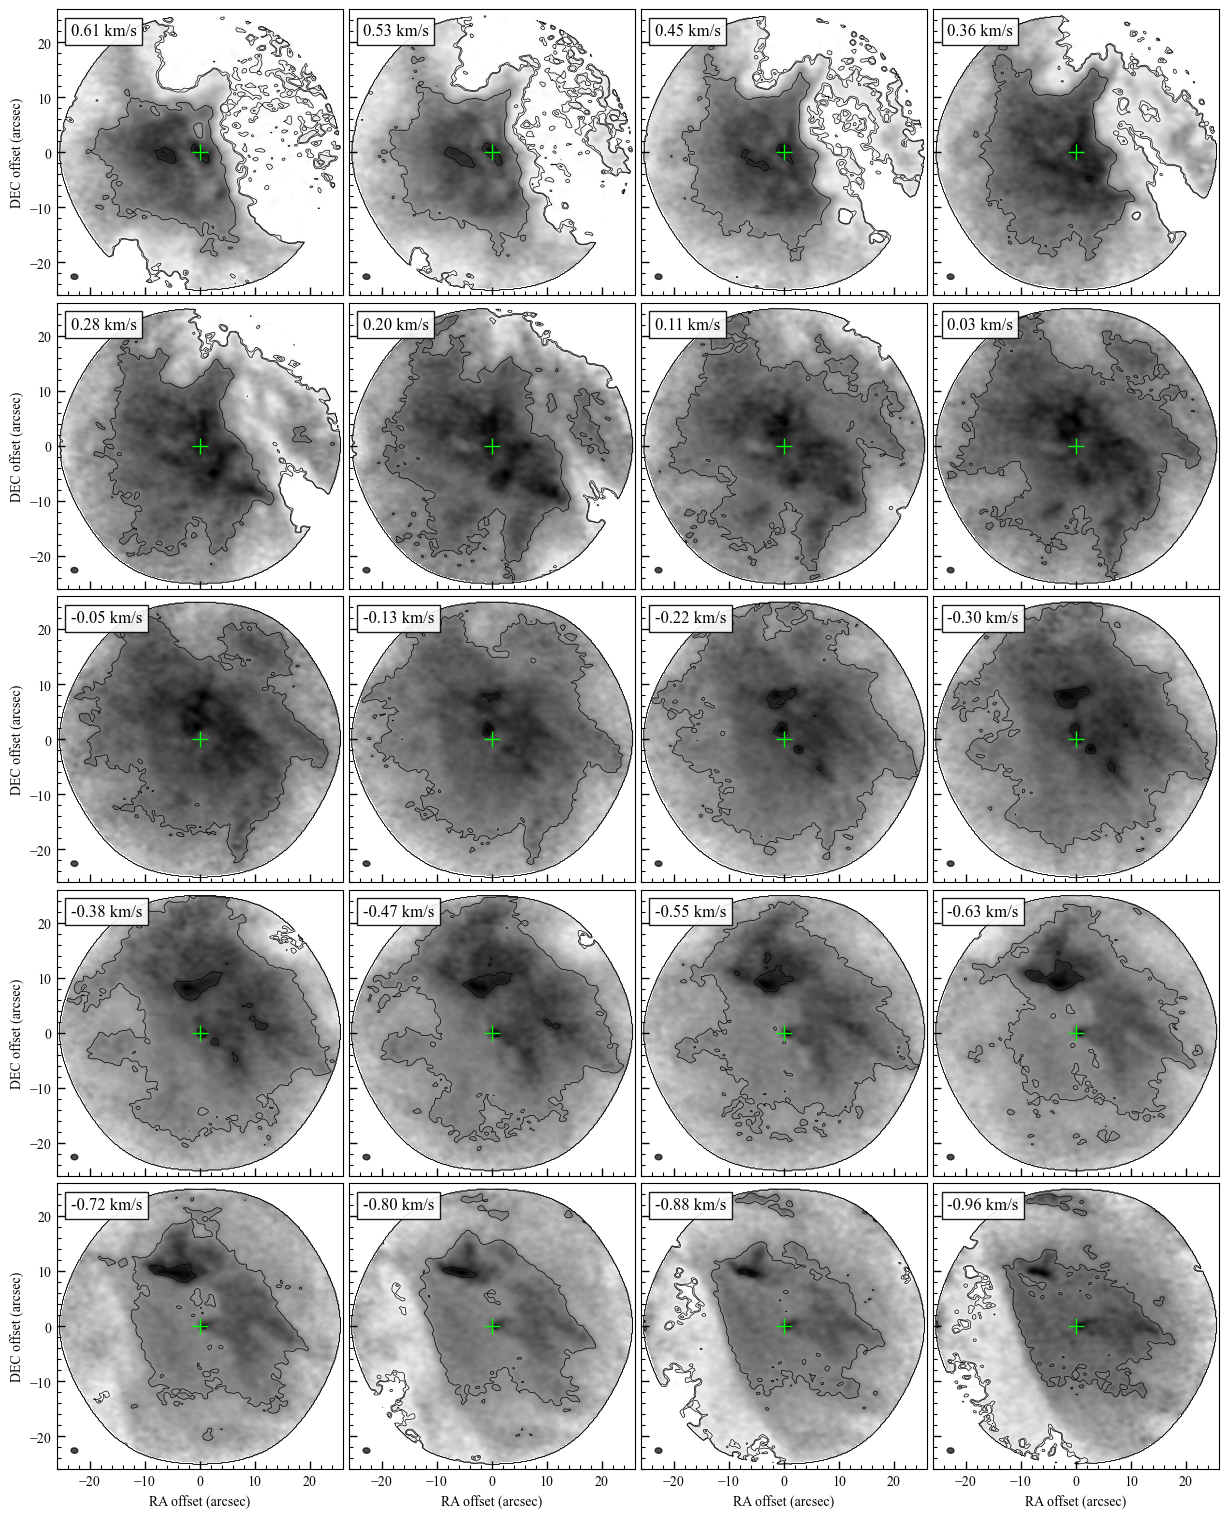

In [ ]:
fig, axes = plt.subplots(5, 4, figsize=(15, 19))

for idx, i in enumerate(range(60, 80)):  
    row = idx // 4  # Calculate the row index (0 to 4)
    col = idx % 4   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Plot the data slice
    im = ax.imshow(cube[i, :, :].value, cmap='binary', origin='lower', vmin=0, extent=[
    ra_offsets.min(), ra_offsets.max(),
    dec_offsets.min(), dec_offsets.max()])

    # Plot contours with proper data handling
    contour_data = np.nan_to_num(cube[i, :, :].value)  # Replace NaNs with zeros
    plot_contours(contour_data, 'black', levels=[3*CO_sigma, 5*CO_sigma, 40*CO_sigma, 75*CO_sigma, 110*CO_sigma, 145*CO_sigma])
    # plot_contours(Mom0_red.value, 'red', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])
    # plot_contours(Mom0_blue.value, 'blue', levels=[30*CO_sigma, 120*CO_sigma, 180*CO_sigma, 240*CO_sigma, 300*CO_sigma, 360*CO_sigma])

    # Get velocity for the current slice
    velocity = cube.spectral_axis[i].to(u.km / u.s).value

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    # Add beam
    beam_13CO = beam(1.29, 1.03, 84.42, 15)
    ax.add_patch(beam_13CO) 

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Only show RA labels on the bottom row
    if row < 4:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (arcsec)')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (arcsec)')

    # Hide tick labels for non-edge plots
    if row < 4:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Jy/beam.km/s')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_13CO_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_13CO_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()